In [378]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1
import numpy as np

import sys
from utils.utils import get_path

import os
from scipy import sparse
from vis_utils.loaders import load_dataset
import matplotlib.pyplot as plt
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from openTSNE.affinity import Affinities
from vis_utils.tsne_wrapper import TSNEwrapper
from ripser import Rips
from mpl_toolkits.axes_grid1 import make_axes_locatable
import tadasets
from ripser import ripser
from persim import plot_diagrams
from matplotlib import collections  as mc

from matplotlib.colors import Normalize
import torch
import pandas as pd



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


<h4 style="background-color: yellow; padding: 5px;">

There appears some big gap in the whole yao's 10x embedding(i.g, lamp5 look like a cloven hoof). This notebooks is to explore the reason. I tried brain area the cells are sampled, which is not the reason. The reason is the sex of the mouse, and then I split the data by sex. Again if you can find folders "yao_10x_female" and "yao_10x_male", no need to run this one.

</h4>

In [379]:
dataset = "yao_10x"
root_path = get_path("data")
x, y, sknn, pca2, d = load_dataset(root_path, dataset)
k = 15
n_epochs = 500
n_early_epochs = 250
perplexity = None
rescale_tsne = True
seed = 0

if rescale_tsne:
    pca_tsne = pca2 / np.std(pca2[:, 0]) / 10000
else:
    pca_tsne = pca2
affinities = Affinities()
affinities.P = (sknn / sknn.sum()).tocsr()

file_name = os.path.join(root_path,
                         dataset,
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")

tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

# Dividing metadat.csv

In [802]:
metadata = pd.read_csv(os.path.join(get_path("data"), "yao/10x_metadata.csv"))

In [803]:
metadata["donor_sex_label"].values[:20]

array(['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
       'F', 'M', 'M', 'M', 'M', 'M', 'M'], dtype=object)

In [ ]:
len(metadata)

1169213

In [823]:
male = metadata[metadata['donor_sex_id'] == 2]

In [ ]:
female = metadata[metadata['donor_sex_id'] == 1]

In [ ]:
len(male)

768325

In [ ]:
len(female)

400888

In [826]:
male.to_csv(os.path.join(get_path("data"), "yao/10x_metadata_male.csv"), index = False)
female.to_csv(os.path.join(get_path("data"), "yao/10x_metadata_female.csv"), index = False)

# embd for whole 10x 

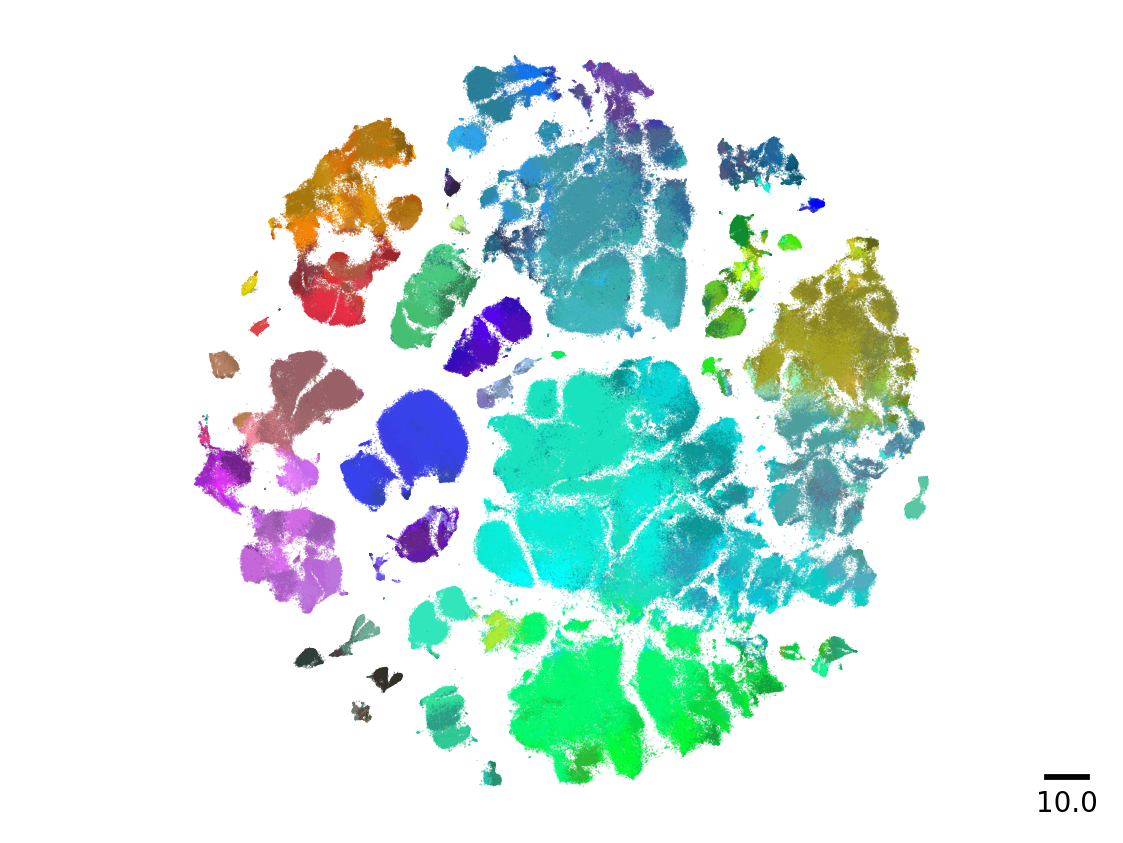

In [ ]:
fig, ax = plt.subplots()
plot_scatter(ax, embd, metadata["cluster_color"])
# fig.savefig(os.path.join(get_path("figures"), f"tsne_embe_yao_10x.png"), dpi=300)

# recolor by sampled brain region

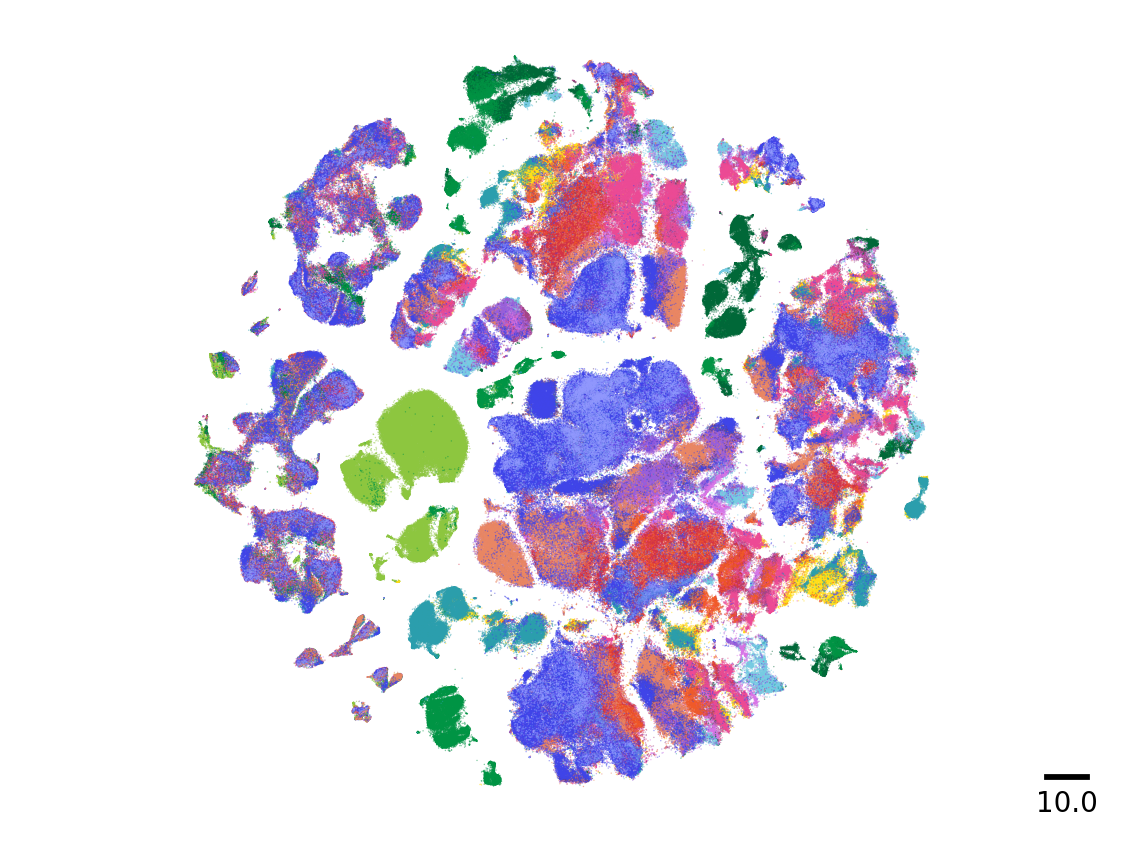

In [830]:
fig, ax = plt.subplots()
plot_scatter(ax, embd, metadata["region_color"])
# fig.savefig(os.path.join(get_path("figures"), f"tsne_embe_yao_10x_region.png"), dpi=300)

In [763]:
for col in metadata.columns[1:]:
    print(f"Distribution for column '{col}':")
    print(metadata[col].value_counts(), "\n")

Distribution for column 'donor_sex_id':
donor_sex_id
2    768325
1    400888
Name: count, dtype: int64 

Distribution for column 'donor_sex_label':
donor_sex_label
M    768325
F    400888
Name: count, dtype: int64 

Distribution for column 'donor_sex_color':
donor_sex_color
#ADC4C3    768325
#565353    400888
Name: count, dtype: int64 

Distribution for column 'region_id':
region_id
2     214496
11    123727
28     82535
7      81050
6      71060
15     71017
20     65710
22     62216
21     59747
19     58219
18     52428
26     51473
8      47094
13     34331
1      29763
5      27333
4      18814
3      18200
Name: count, dtype: int64 

Distribution for column 'region_label':
region_label
VIS                      214496
MOp                      123727
HIP                       82535
SSp                       81050
AUD                       71060
PL-ILA-ORB                71017
RSP                       65710
ENT                       62216
TEa-PERI-ECT              59747
ACA        

# recolor by sex

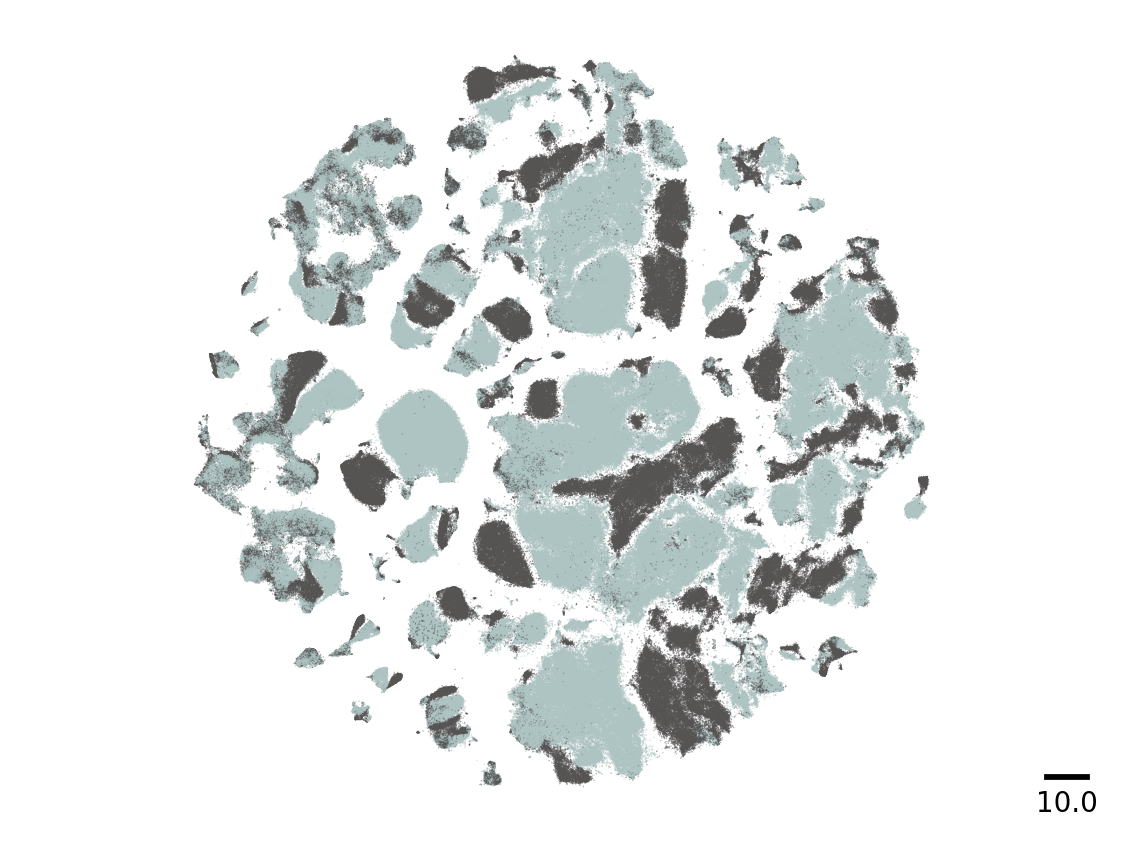

In [829]:
fig, ax = plt.subplots()
plot_scatter(ax, embd, metadata["donor_sex_color"])
# fig.savefig(os.path.join(get_path("figures"), f"tsne_embe_yao_10x_sex.png"), dpi=300)